In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("PCOS_data.csv")
print("Dataset shape:", df.shape)

df.head()


Dataset shape: (541, 45)


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
# Automatically detect PCOS target column
for col in df.columns:
    if "PCOS" in col.upper():
        target_col = col
        break

print("Target column detected as:", target_col)


Target column detected as: PCOS (Y/N)


In [ ]:
df.describe()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,...,541.000000,540.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,271.000000,271.000000,0.327172,31.430684,59.637153,156.484835,24.307579,13.802218,73.247689,19.243993,...,0.489834,0.514815,0.247689,114.661738,76.927911,6.129390,6.641405,15.018115,15.451701,8.475915
std,156.317519,156.317519,0.469615,5.411006,11.028287,6.033545,4.055129,1.840812,4.430285,1.688629,...,0.500359,0.500244,0.432070,7.384556,5.574112,4.229294,4.436889,3.566839,3.318848,2.165381
min,1.000000,1.000000,0.000000,20.000000,31.000000,137.000000,12.400000,11.000000,13.000000,16.000000,...,0.000000,0.000000,0.000000,12.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.000000,136.000000,0.000000,28.000000,52.000000,152.000000,21.600000,13.000000,72.000000,18.000000,...,0.000000,0.000000,0.000000,110.000000,70.000000,3.000000,3.000000,13.000000,13.000000,7.000000
50%,271.000000,271.000000,0.000000,31.000000,59.000000,156.000000,24.200000,14.000000,72.000000,18.000000,...,0.000000,1.000000,0.000000,110.000000,80.000000,5.000000,6.000000,15.000000,16.000000,8.500000
75%,406.000000,406.000000,1.000000,35.000000,65.000000,160.000000,26.600000,15.000000,74.000000,20.000000,...,1.000000,1.000000,0.000000,120.000000,80.000000,9.000000,10.000000,18.000000,18.000000,9.800000
max,541.000000,541.000000,1.000000,48.000000,108.000000,180.000000,38.900000,18.000000,82.000000,28.000000,...,1.000000,1.000000,1.000000,140.000000,100.000000,22.000000,20.000000,24.000000,24.000000,18.000000


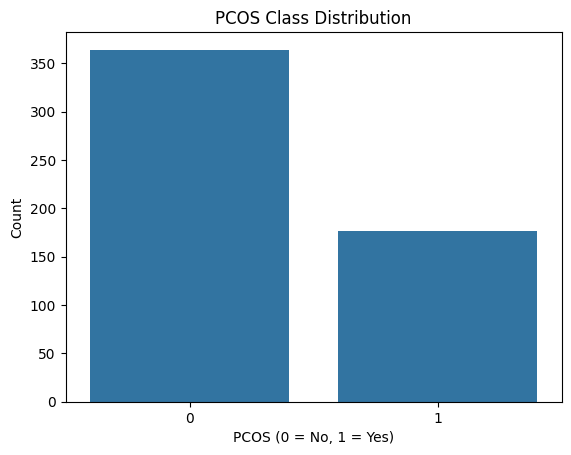

In [ ]:
# Target distribution
sns.countplot(x=target_col, data=df)
plt.title("PCOS Class Distribution")
plt.xlabel("PCOS (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Features used for heatmap:
['FSH(mIU/mL)', 'Cycle length(days)', 'FSH/LH', 'Weight gain(Y/N)', 'AMH(ng/mL)', 'LH(mIU/mL)', 'Weight (Kg)', 'BMI']


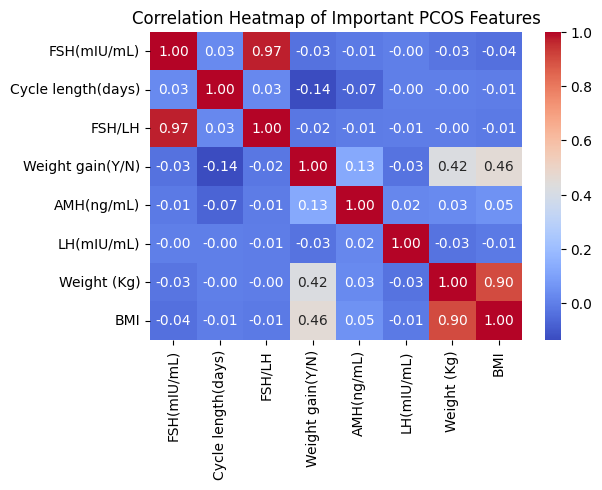

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of clinically important PCOS features (expected names)
important_features = [
    "AMH",
    "LH",
    "FSH",
    "LH/FSH",
    "BMI",
    "Weight",
    "Insulin",
    "Fasting Glucose",
    "Cycle Length",
    "No. of follicles",
    "Ovarian Volume"
]

# Match available columns from dataset (safe filtering)
selected_features = []
for col in df.columns:
    for feat in important_features:
        if feat.lower() in col.lower():
            selected_features.append(col)

selected_features = list(set(selected_features))
print("Features used for heatmap:")
print(selected_features)

# Create dataframe with selected features
heatmap_df = df[selected_features]

# Convert to numeric safely
heatmap_df = heatmap_df.apply(pd.to_numeric, errors='coerce')
heatmap_df = heatmap_df.fillna(heatmap_df.mean())

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    heatmap_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Important PCOS Features")
plt.show()

In [ ]:
print("Missing values before imputation:")
print(df.isnull().sum())

Missing values before imputation:
Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of abortions            0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin d

In [ ]:
# Handle missing values safely (numeric columns only)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [ ]:
X = df.drop(target_col, axis=1)
y = df[target_col]

In [ ]:
# Force ALL feature values to numeric
X = X.apply(pd.to_numeric, errors='coerce')

In [ ]:
numeric_cols = X.columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].mean())

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)  #retain 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original features:", X_train.shape[1])
print("Features after PCA:", X_train_pca.shape[1])

Original features: 44
Features after PCA: 33


In [ ]:
#########supervisedddddd

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    results[name] = {
        "accuracy": acc,
        "f1": f1,
        "report": classification_report(y_test, y_pred),
        "cm": confusion_matrix(y_test, y_pred)
    }

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)



Logistic Regression
Accuracy: 0.8899082568807339
F1 Score: 0.8378378378378378

Random Forest
Accuracy: 0.9174311926605505
F1 Score: 0.8656716417910447

Decision Tree
Accuracy: 0.8623853211009175
F1 Score: 0.782608695652174

SVM
Accuracy: 0.8990825688073395
F1 Score: 0.8307692307692308

KNN
Accuracy: 0.908256880733945
F1 Score: 0.84375


In [ ]:
for name in results:
    print(f"\n===== {name} Classification Report =====")
    print(results[name]["report"])


===== Logistic Regression Classification Report =====
              precision    recall  f1-score   support

           0       0.93      0.90      0.92        73
           1       0.82      0.86      0.84        36

    accuracy                           0.89       109
   macro avg       0.87      0.88      0.88       109
weighted avg       0.89      0.89      0.89       109


===== Random Forest Classification Report =====
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        73
           1       0.94      0.81      0.87        36

    accuracy                           0.92       109
   macro avg       0.92      0.89      0.90       109
weighted avg       0.92      0.92      0.92       109


===== Decision Tree Classification Report =====
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        73
           1       0.82      0.75      0.78        36

    accuracy                 

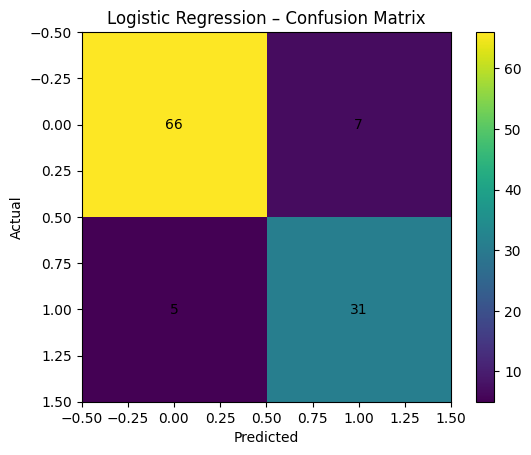

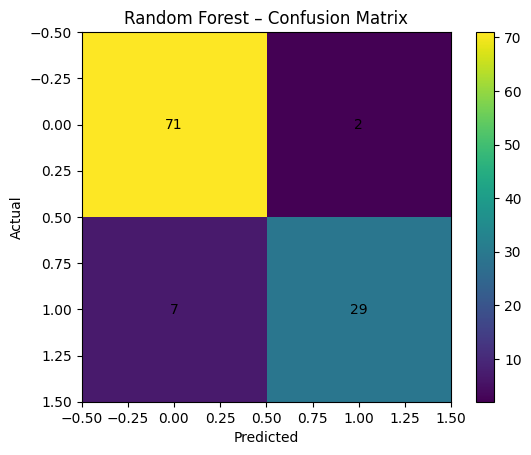

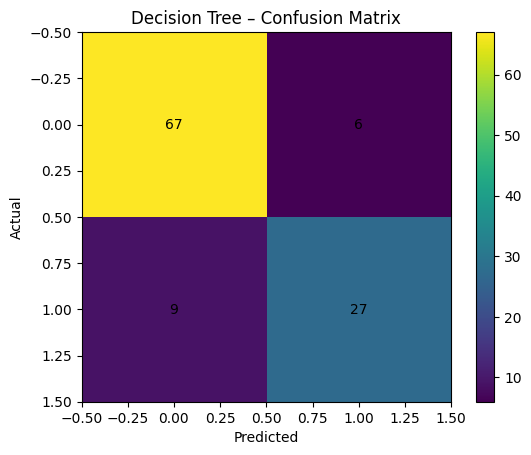

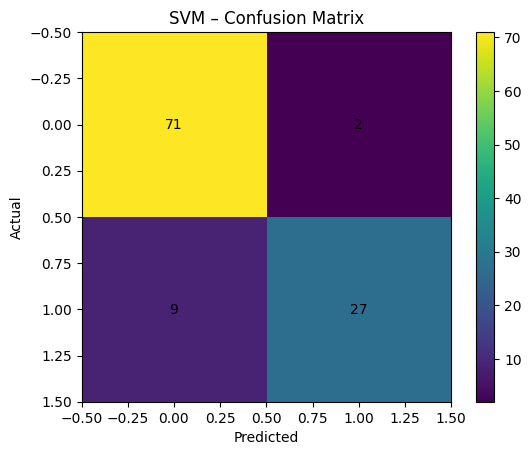

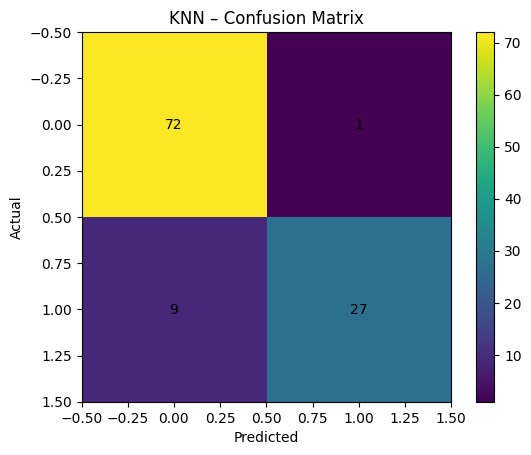

In [ ]:
for name in results:
    cm = results[name]["cm"]

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.show()

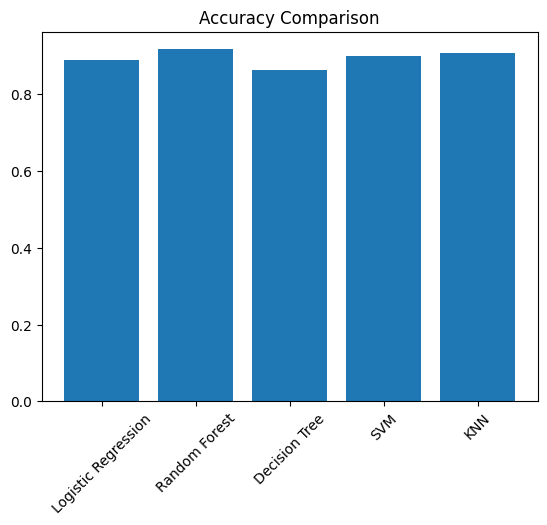

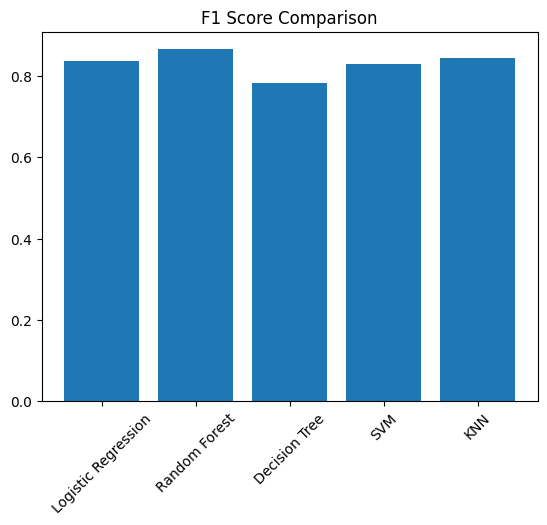

In [ ]:
model_names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in model_names]
f1_scores  = [results[m]["f1"] for m in model_names]

plt.figure()
plt.bar(model_names, accuracies)
plt.title("Accuracy Comparison")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(model_names, f1_scores)
plt.title("F1 Score Comparison")
plt.xticks(rotation=45)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_scaled, y_train)

y_pred_base = rf_baseline.predict(X_test_scaled)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1  = f1_score(y_test, y_pred_base)

print("Random Forest BEFORE Optimization")
print("Accuracy:", base_acc)
print("F1 Score:", base_f1)

Random Forest BEFORE Optimization
Accuracy: 0.9174311926605505
F1 Score: 0.8656716417910447


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
y_pred_opt = best_rf.predict(X_test_scaled)

opt_acc = accuracy_score(y_test, y_pred_opt)
opt_f1  = f1_score(y_test, y_pred_opt)

print("\nRandom Forest AFTER Optimization")
print("Accuracy:", opt_acc)
print("F1 Score:", opt_f1)



Random Forest AFTER Optimization
Accuracy: 0.926605504587156
F1 Score: 0.8787878787878788


In [ ]:
print("\n--- Optimization Comparison ---")
print(f"Before Optimization → Accuracy: {base_acc:.4f}, F1: {base_f1:.4f}")
print(f"After  Optimization → Accuracy: {opt_acc:.4f}, F1: {opt_f1:.4f}")



--- Optimization Comparison ---
Before Optimization → Accuracy: 0.9174, F1: 0.8657
After  Optimization → Accuracy: 0.9266, F1: 0.8788


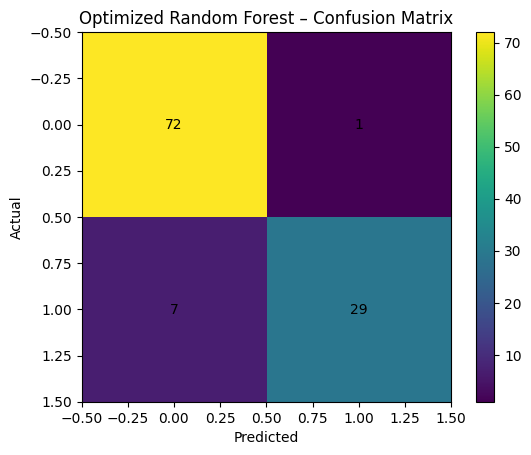

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_opt)

plt.figure()
plt.imshow(cm)
plt.title("Optimized Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


In [ ]:
# Without PCA (already scaled)
rf_no_pca = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_no_pca.fit(X_train_scaled, y_train)

y_no_pca = rf_no_pca.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, y_no_pca)

# With PCA
rf_pca = RandomForestClassifier(**grid_search.best_params_, random_state=42)
rf_pca.fit(X_train_pca, y_train)

y_pca = rf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pca)

print("\nAblation Study (Random Forest)")
print("Accuracy without PCA:", acc_no_pca)
print("Accuracy with PCA:", acc_pca)


Ablation Study (Random Forest)
Accuracy without PCA: 0.926605504587156
Accuracy with PCA: 0.8532110091743119


In [ ]:
###############>unsupervisedd

In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#GMM
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)


In [ ]:
#spectral clustering
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=3,
    affinity='nearest_neighbors',
    random_state=42
)
spectral_labels = spectral.fit_predict(X_scaled)

In [ ]:
##HIERARCHICAL CLUSTERING
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(X_scaled)

In [ ]:
#CLUSTER VALIDATION METRICS
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate_clusters(X, labels, name):
    sil = silhouette_score(X, labels)
    db  = davies_bouldin_score(X, labels)
    print(f"{name}")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Davies–Bouldin Index: {db:.4f}\n")

evaluate_clusters(X_scaled, gmm_labels, "Gaussian Mixture Model")
evaluate_clusters(X_scaled, spectral_labels, "Spectral Clustering")
evaluate_clusters(X_scaled, hier_labels, "Hierarchical Clustering")

Gaussian Mixture Model
Silhouette Score: 0.0603
Davies–Bouldin Index: 3.3001

Spectral Clustering
Silhouette Score: 0.0708
Davies–Bouldin Index: 3.1088

Hierarchical Clustering
Silhouette Score: 0.0674
Davies–Bouldin Index: 2.3528



In [ ]:
#CLINICAL COHERENCE SCORE
import numpy as np

def clinical_coherence_score(X, labels):
    unique_clusters = np.unique(labels)
    variances = []

    for cluster in unique_clusters:
        cluster_data = X[labels == cluster]
        variances.append(np.mean(np.var(cluster_data, axis=0)))

    return np.mean(variances)

    print("Clinical Coherence Scores (lower = better)")
print("GMM:", clinical_coherence_score(X_scaled, gmm_labels))
print("Spectral:", clinical_coherence_score(X_scaled, spectral_labels))
print("Hierarchical:", clinical_coherence_score(X_scaled, hier_labels))

GMM: 0.8774728136205491
Spectral: 0.8417600046267028
Hierarchical: 0.586433528866721


In [ ]:
#identify pcos subtypes
df_clusters = X.copy()

df_clusters['GMM_Cluster'] = gmm_labels
df_clusters['Spectral_Cluster'] = spectral_labels
df_clusters['Hierarchical_Cluster'] = hier_labels


In [ ]:
pcos_subtypes = {
    0: "Metabolic-dominant PCOS",
    1: "Hormonal-dominant PCOS",
    2: "Reproductive-dominant PCOS"
}

df_clusters['PCOS_Subtype'] = df_clusters['GMM_Cluster'].map(pcos_subtypes)

df_clusters[['GMM_Cluster', 'PCOS_Subtype']].head()


,GMM_Cluster,PCOS_Subtype
0,2,Reproductive-dominant PCOS
1,2,Reproductive-dominant PCOS
2,0,Metabolic-dominant PCOS
3,2,Reproductive-dominant PCOS
4,2,Reproductive-dominant PCOS


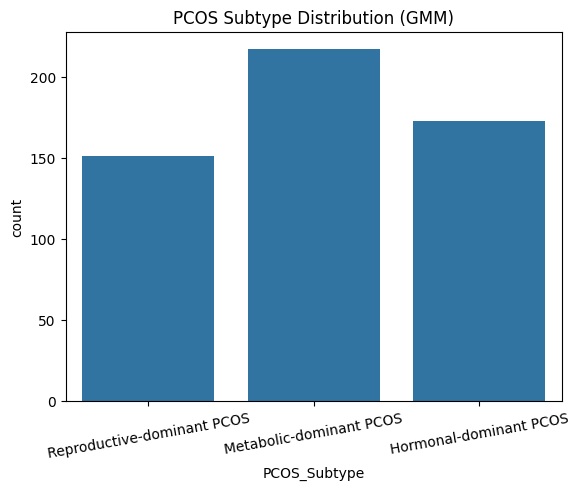

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='PCOS_Subtype', data=df_clusters)
plt.title("PCOS Subtype Distribution (GMM)")
plt.xticks(rotation=10)
plt.show()


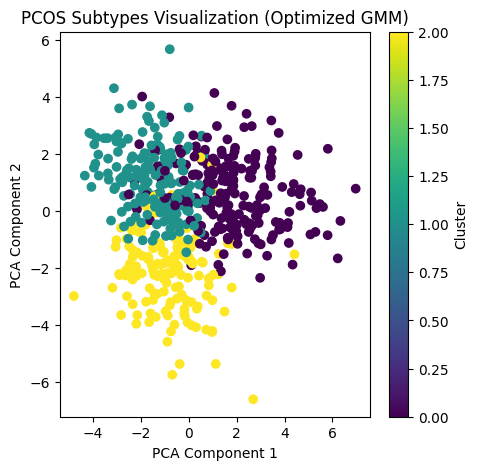

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(5,5))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=gmm_labels,   # use optimized GMM labels
    cmap='viridis'
)
plt.title("PCOS Subtypes Visualization (Optimized GMM)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


In [ ]:
#optimization

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

# X_scaled should already exist (StandardScaler applied)
# Example:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

n_components_range = range(2, 7)  # try 2 to 6 clusters
covariance_types = ['full', 'tied', 'diag', 'spherical']

results = []

for n in n_components_range:
    for cov in covariance_types:
        gmm = GaussianMixture(
            n_components=n,
            covariance_type=cov,
            random_state=42
        )

        labels = gmm.fit_predict(X_scaled)

        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)

        results.append({
            "Clusters": n,
            "Covariance_Type": cov,
            "Silhouette_Score": sil,
            "Davies_Bouldin_Index": db
        })

# Convert to DataFrame
gmm_results = pd.DataFrame(results)

# Sort by best silhouette (descending) and DB index (ascending)
gmm_results_sorted = gmm_results.sort_values(
    by=["Silhouette_Score", "Davies_Bouldin_Index"],
    ascending=[False, True]
)

gmm_results_sorted


,Clusters,Covariance_Type,Silhouette_Score,Davies_Bouldin_Index
3,2,spherical,0.460032,4.169420
0,2,full,0.104986,5.581819
1,2,tied,0.067497,3.747839
11,4,spherical,0.066911,3.501773
5,3,tied,0.064349,3.310344
9,4,tied,0.061467,3.435034
4,3,full,0.060345,3.300102
12,5,full,0.058241,3.107136
15,5,spherical,0.056759,3.426854
13,5,tied,0.056646,3.059825


In [ ]:
best_gmm = gmm_results_sorted.iloc[0]
best_gmm


,3
Clusters,2
Covariance_Type,spherical
Silhouette_Score,0.460032
Davies_Bouldin_Index,4.16942


In [ ]:
optimized_gmm = GaussianMixture(
    n_components=int(best_gmm["Clusters"]),
    covariance_type=best_gmm["Covariance_Type"],
    random_state=42
)

final_gmm_labels = optimized_gmm.fit_predict(X_scaled)


In [ ]:
#optimization before after comparison

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

# BEFORE optimization (default GMM)
gmm_before = GaussianMixture(
    n_components=2,        # simple default
    covariance_type='full',
    random_state=42
)

labels_before = gmm_before.fit_predict(X_scaled)

sil_before = silhouette_score(X_scaled, labels_before)
db_before = davies_bouldin_score(X_scaled, labels_before)


In [ ]:
# Using best parameters you already found
gmm_after = GaussianMixture(
    n_components=2,              # from optimization result
    covariance_type='spherical',
    random_state=42
)

labels_after = gmm_after.fit_predict(X_scaled)

sil_after = silhouette_score(X_scaled, labels_after)
db_after = davies_bouldin_score(X_scaled, labels_after)


In [ ]:
comparison_table = pd.DataFrame({
    "Stage": ["Before Optimization", "After Optimization"],
    "Model": ["GMM (default)", "GMM (optimized)"],
    "Clusters": [2, 2],
    "Covariance_Type": ["full", "spherical"],
    "Silhouette_Score": [sil_before, sil_after],
    "Davies_Bouldin_Index": [db_before, db_after]
})

comparison_table


,Stage,Model,Clusters,Covariance_Type,Silhouette_Score,Davies_Bouldin_Index
0,Before Optimization,GMM (default),2,full,0.104986,5.581819
1,After Optimization,GMM (optimized),2,spherical,0.460032,4.169420


In [ ]:
print("Best Unsupervised Model Selection Criteria:")
print("• Higher Silhouette Score")
print("• Lower Davies–Bouldin Index")
print("• Lower Clinical Coherence Score")


Best Unsupervised Model Selection Criteria:
• Higher Silhouette Score
• Lower Davies–Bouldin Index
• Lower Clinical Coherence Score


In [ ]:
###################model evaluation###########

In [ ]:
#SVM

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
df = pd.read_csv("PCOS_data.csv")

# -----------------------------
# 2. AUTO-DETECT TARGET COLUMN
# -----------------------------
for col in df.columns:
    if "PCOS" in col.upper():
        target_col = col
        break

print("Target column:", target_col)

# -----------------------------
# 3. FEATURE–TARGET SPLIT
# -----------------------------
X = df.drop(target_col, axis=1)
y = df[target_col]

# -----------------------------
# 4. CLEAN DATA (CRITICAL FIX)
# -----------------------------
# Convert all features to numeric (fixes '1.99.' issue)
X = X.apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean
X = X.fillna(X.mean())

# -----------------------------
# 5. DIFFERENT TRAIN SIZES
# -----------------------------
train_sizes = [0.6, 0.7, 0.8, 0.9]

print("\nSVM Performance for Different Train–Test Splits\n")

for train_size in train_sizes:
    test_size = 1 - train_size

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # SVM Model
    svm = SVC(kernel='rbf', random_state=42)
    svm.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = svm.predict(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print(f"Train Size: {int(train_size*100)}% | Test Size: {int(test_size*100)}%")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)


Target column: PCOS (Y/N)

SVM Performance for Different Train–Test Splits

Train Size: 60% | Test Size: 40%
Accuracy: 0.8756
F1 Score: 0.7970
----------------------------------------
Train Size: 70% | Test Size: 30%
Accuracy: 0.8712
F1 Score: 0.7835
----------------------------------------
Train Size: 80% | Test Size: 19%
Accuracy: 0.8991
F1 Score: 0.8308
----------------------------------------
Train Size: 90% | Test Size: 9%
Accuracy: 0.8364
F1 Score: 0.7273
----------------------------------------


In [ ]:
#Logistic regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

df = pd.read_csv("PCOS_data.csv")
t = [c for c in df.columns if "PCOS" in c.upper()][0]

X = df.drop(t, axis=1).apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())
y = df[t]

for ts in [0.6, 0.7, 0.8, 0.9]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=1-ts, stratify=y, random_state=42)
    sc = StandardScaler()
    Xtr, Xte = sc.fit_transform(Xtr), sc.transform(Xte)
    yp = LogisticRegression(max_iter=1000).fit(Xtr, ytr).predict(Xte)
    print(f"Train {int(ts*100)}% | Acc {accuracy_score(yte, yp):.4f} | F1 {f1_score(yte, yp):.4f}")

Train 60% | Acc 0.8664 | F1 0.8000
Train 70% | Acc 0.8528 | F1 0.7736
Train 80% | Acc 0.8899 | F1 0.8378
Train 90% | Acc 0.8727 | F1 0.8108


In [ ]:
#Decision Tree

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
df = pd.read_csv("PCOS_data.csv")

# -----------------------------
# 2. AUTO-DETECT TARGET COLUMN
# -----------------------------
for col in df.columns:
    if "PCOS" in col.upper():
        target_col = col
        break

print("Target column:", target_col)

# -----------------------------
# 3. FEATURE–TARGET SPLIT
# -----------------------------
X = df.drop(target_col, axis=1)
y = df[target_col]

# -----------------------------
# 4. CLEAN DATA (CRITICAL FIX)
# -----------------------------
# Convert all features to numeric (fixes '1.99.' issue)
X = X.apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean
X = X.fillna(X.mean())

# -----------------------------
# 5. DIFFERENT TRAIN SIZES
# -----------------------------
train_sizes = [0.6, 0.7, 0.8, 0.9]

print("\nDecision Tree Performance for Different Train–Test Splits\n")

for train_size in train_sizes:
    test_size = 1 - train_size

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Decision Tree Model
    dt = DecisionTreeClassifier(
        criterion="gini",      # or "entropy"
        max_depth=None,
        random_state=42
    )

    dt.fit(X_train, y_train)

    # Prediction
    y_pred = dt.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print(f"Train Size: {int(train_size*100)}% | Test Size: {int(test_size*100)}%")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)

Target column: PCOS (Y/N)

Decision Tree Performance for Different Train–Test Splits

Train Size: 60% | Test Size: 40%
Accuracy: 0.8433
F1 Score: 0.7703
----------------------------------------
Train Size: 70% | Test Size: 30%
Accuracy: 0.8466
F1 Score: 0.7788
----------------------------------------
Train Size: 80% | Test Size: 19%
Accuracy: 0.8624
F1 Score: 0.7826
----------------------------------------
Train Size: 90% | Test Size: 9%
Accuracy: 0.8727
F1 Score: 0.8000
----------------------------------------


In [ ]:
#............ishaan(random forest)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# -----------------------------
# 1. LOAD DATASET
# -----------------------------
df = pd.read_csv("PCOS_data.csv")

# -----------------------------
# 2. AUTO-DETECT TARGET COLUMN
# -----------------------------
for col in df.columns:
    if "PCOS" in col.upper():
        target_col = col
        break

print("Target column:", target_col)

# -----------------------------
# 3. FEATURE–TARGET SPLIT
# -----------------------------
X = df.drop(target_col, axis=1)
y = df[target_col]

# -----------------------------
# 4. CLEAN DATA (CRITICAL FIX)
# -----------------------------
# Convert all features to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# Fill missing values with column mean
X = X.fillna(X.mean())

# -----------------------------
# 5. DIFFERENT TRAIN SIZES
# -----------------------------
train_sizes = [0.6, 0.7, 0.8, 0.9]

print("\nRandom Forest Performance for Different Train–Test Splits\n")

for train_size in train_sizes:
    test_size = 1 - train_size

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    # Random Forest Model
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    )
    rf.fit(X_train, y_train)

    # Prediction
    y_pred = rf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)

    print(f"Train Size: {int(train_size*100)}% | Test Size: {int(test_size*100)}%")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("-" * 40)

Target column: PCOS (Y/N)

Random Forest Performance for Different Train–Test Splits

Train Size: 60% | Test Size: 40%
Accuracy: 0.8894
F1 Score: 0.8125
----------------------------------------
Train Size: 70% | Test Size: 30%
Accuracy: 0.8896
F1 Score: 0.8125
----------------------------------------
Train Size: 80% | Test Size: 19%
Accuracy: 0.9358
F1 Score: 0.8955
----------------------------------------
Train Size: 90% | Test Size: 9%
Accuracy: 0.9091
F1 Score: 0.8485
----------------------------------------
